In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA 
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("university_admission.csv")

In [3]:
df.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GRE_Score            1000 non-null   int64  
 1   TOEFL_Score          1000 non-null   int64  
 2   University_Rating    1000 non-null   int64  
 3   SOP                  1000 non-null   float64
 4   LOR                  1000 non-null   float64
 5   CGPA                 1000 non-null   float64
 6   Research             1000 non-null   int64  
 7   Chance_of_Admission  1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


In [6]:
df.isnull().sum()

GRE_Score              0
TOEFL_Score            0
University_Rating      0
SOP                    0
LOR                    0
CGPA                   0
Research               0
Chance_of_Admission    0
dtype: int64

In [7]:
# df.duplicated().sum()

In [8]:
df = df.drop(columns=["Chance_of_Admission"])

In [9]:
df

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
995,332,108,5,4.5,4.0,9.02,1
996,337,117,5,5.0,5.0,9.87,1
997,330,120,5,4.5,5.0,9.56,1
998,312,103,4,4.0,5.0,8.43,0


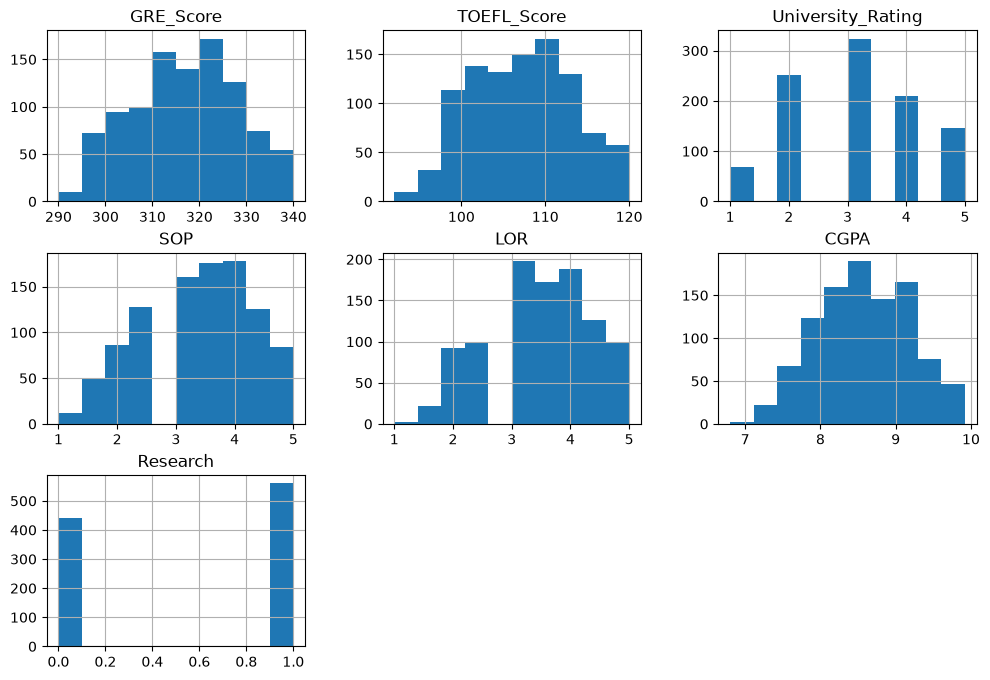

In [10]:
df.hist(figsize=(12,8))
plt.show()

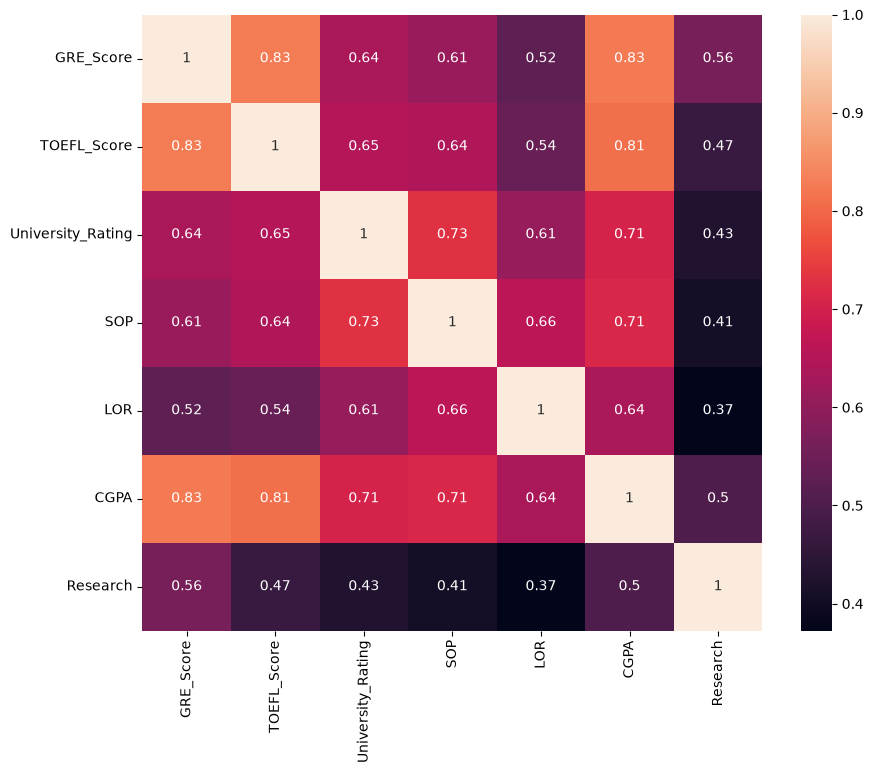

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [12]:
X = df

In [13]:
# Feature scaling 
scaler = StandardScaler()
X = scaler.fit_transform(df)

In [14]:
#Elbow Method

In [15]:
wcss = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    wcss.append(model.inertia_)

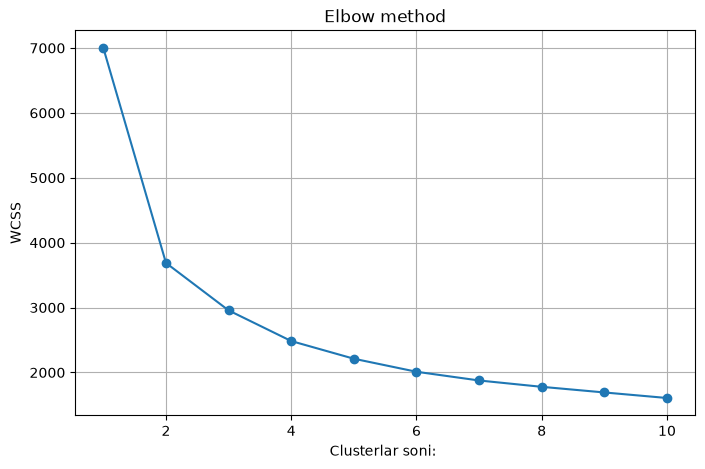

In [16]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Clusterlar soni: ")
plt.ylabel("WCSS")
plt.title("Elbow method")
plt.grid(True)
plt.show()

In [17]:
# model training

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

In [18]:
df["Clusters"] = clusters

In [19]:
df

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Clusters
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,3
3,322,110,3,3.5,2.5,8.67,1,3
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
995,332,108,5,4.5,4.0,9.02,1,1
996,337,117,5,5.0,5.0,9.87,1,1
997,330,120,5,4.5,5.0,9.56,1,1
998,312,103,4,4.0,5.0,8.43,0,2


In [20]:
df["Clusters"].value_counts()

Clusters
3    272
1    260
2    250
0    218
Name: count, dtype: int64

In [21]:
df.groupby("Clusters").mean(numeric_only=True)

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
Clusters,,,,,,,
0,303.807339,100.385321,1.880734,2.174312,2.504587,7.863486,0.220183
1,329.423077,114.230769,4.446154,4.446154,4.373077,9.311923,0.923077
2,311.864000,105.480000,2.912000,3.336000,3.468000,8.431360,0.000000
3,318.477941,107.496324,3.014706,3.345588,3.433824,8.578162,1.000000


In [22]:
score=silhouette_score(X, clusters)
print(score)

0.27913710362381416


In [23]:
# # cluster markazlari

# centers = scaler.inverse_transform(kmeans.cluster_centers_)

# centers = pd.DataFrame(centers, 
#                        columns=df.drop(columns="Clusters").columns)

# centers

In [24]:
df

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Clusters
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,3
3,322,110,3,3.5,2.5,8.67,1,3
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
995,332,108,5,4.5,4.0,9.02,1,1
996,337,117,5,5.0,5.0,9.87,1,1
997,330,120,5,4.5,5.0,9.56,1,1
998,312,103,4,4.0,5.0,8.43,0,2


In [25]:
pca = PCA(n_components=2, random_state=42) # principal component analysis
X_pca = pca.fit_transform(X)

print(f"Bu 2 komponent ma'lumotdagi umumiy o'zgaruvchanlikning "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%ini tushuntiradi")

Bu 2 komponent ma'lumotdagi umumiy o'zgaruvchanlikning 78.1%ini tushuntiradi


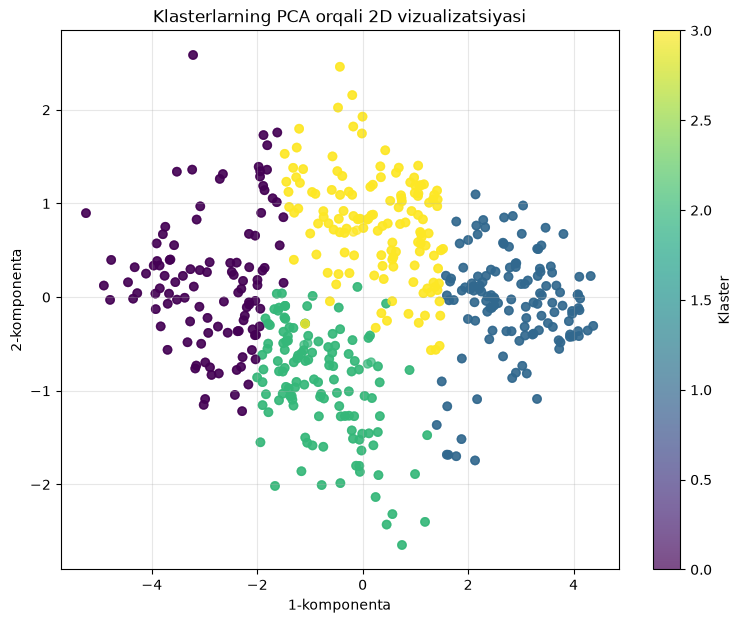

In [26]:
plt.figure(figsize=(9,7))
sochilish = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Clusters"], cmap="viridis", alpha=0.7)
plt.xlabel("1-komponenta")
plt.ylabel("2-komponenta")
plt.title("Klasterlarning PCA orqali 2D vizualizatsiyasi")
plt.colorbar(sochilish, label="Klaster")
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# Klaster markazlarini asl (scale qilinmagan) birliklarga qaytaramiz
markazlar = scaler.inverse_transform(kmeans.cluster_centers_)

markazlar_df = pd.DataFrame(
    markazlar,
    columns=df.drop(columns="Clusters").columns
)
markazlar_df.index.name = "Klaster"
markazlar_df.round(2)

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
Klaster,,,,,,,
0,303.81,100.39,1.88,2.17,2.50,7.86,0.22
1,329.42,114.23,4.45,4.45,4.37,9.31,0.92
2,311.86,105.48,2.91,3.34,3.47,8.43,0.00
3,318.48,107.50,3.01,3.35,3.43,8.58,1.00


In [28]:
# Uchta gipotetik yangi abituriyent (hali ma'lumotlar bazasida yo'q)
yangi_abituriyentlar = pd.DataFrame({
    "GRE_Score":          [335, 300, 318],
    "TOEFL_Score":        [116, 96,  108],
    "University_Rating":  [5,   2,   3],
    "SOP":                [4.5, 2.0, 3.5],
    "LOR":                [4.5, 2.5, 3.0],
    "CGPA":               [9.6, 7.2, 8.5],
    "Research":           [1,   0,   1],
})

yangi_abituriyentlar


,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
0,335,116,5,4.5,4.5,9.6,1
1,300,96,2,2.0,2.5,7.2,0
2,318,108,3,3.5,3.0,8.5,1


In [29]:
yangi_X = scaler.transform(yangi_abituriyentlar)

bashorat = kmeans.predict(yangi_X)

yangi_abituriyentlar["Bashorat_qilingan_klaster"] = bashorat
yangi_abituriyentlar

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Bashorat_qilingan_klaster
0,335,116,5,4.5,4.5,9.6,1,1
1,300,96,2,2.0,2.5,7.2,0,0
2,318,108,3,3.5,3.0,8.5,1,3


In [30]:
markazlar_df

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research
Klaster,,,,,,,
0,303.807339,100.385321,1.880734,2.174312,2.504587,7.863486,2.201835e-01
1,329.423077,114.230769,4.446154,4.446154,4.373077,9.311923,9.230769e-01
2,311.864000,105.480000,2.912000,3.336000,3.468000,8.431360,3.330669e-16
3,318.477941,107.496324,3.014706,3.345588,3.433824,8.578162,1.000000e+00


In [31]:
import joblib

joblib.dump(markazlar_df, 'university_pkl')
joblib.dump(scaler, 'scaler.pkl')
print("model 'university_pkl' va scaler 'scaler.pkl' fayllariga saqlandi")

model 'university_pkl' va scaler 'scaler.pkl' fayllariga saqlandi
